In [ ]:
#Bolortulga Seded
#BIg data analytics - accidental drug related deaths 2012 -2024

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde

df = pd.read_csv('Accidental_Drug_Related_Deaths_2012-2024.csv', low_memory=False)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year

In [10]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nMissing values:\n", 
      df.isnull().sum().sort_values(ascending=False).head(10))
print("\nData types\n", df.dtypes)

Shape: (12963, 49)

Columns: ['Date', 'Date Type', 'Age', 'Sex', 'Race', 'Ethnicity', 'Residence City', 'Residence County', 'Residence State', 'Injury City', 'Injury County', 'Injury State', 'Injury Place', 'Description of Injury', 'Death City', 'Death County', 'Death State', 'Location', 'Location if Other', 'Cause of Death', 'Manner of Death', 'Other Significant Conditions ', 'Heroin', 'Heroin death certificate (DC)', 'Cocaine', 'Fentanyl', 'Fentanyl Analogue', 'Oxycodone', 'Oxymorphone', 'Ethanol', 'Hydrocodone', 'Benzodiazepine', 'Methadone', 'Meth/Amphetamine', 'Amphet', 'Tramad', 'Hydromorphone', 'Morphine (Not Heroin)', 'Xylazine', 'Gabapentin', 'Opiate NOS', 'Heroin/Morph/Codeine', 'Other Opioid', 'Any Opioid', 'Other', 'ResidenceCityGeo', 'InjuryCityGeo', 'DeathCityGeo', 'Year']

Missing values:
 Morphine (Not Heroin)    12901
Hydromorphone            12883
Meth/Amphetamine         12836
Opiate NOS               12835
Hydrocodone              12790
Oxymorphone              1278

In [11]:
print("Age Statistics:")
print(df['Age'].describe().round(2))

print ("\nDeath by sex:")
print(df['Sex'].value_counts())

print("\nDeaths by year:")
print(df.groupby('Year').size())

substance_cols = ['Heroin','Cocaine','Fentanyl','Ethanol','Benzodiazepine','Methadone','Xylazine']

print("\nSubstance detection counts:")
for col in substance_cols:
    count = (df[col] == 'Y').sum()
    pct = count / len(df) *100
    print(f" {col}: {count} ({pct:.1f}%)")

Age Statistics:
count    12961.00
mean        44.35
std         12.71
min         13.00
25%         34.00
50%         44.00
75%         55.00
max         87.00
Name: Age, dtype: float64

Death by sex:
Sex
Male       9571
Female     3380
Unknown       2
X             1
Name: count, dtype: int64

Deaths by year:
Year
2012     355
2013     490
2014     558
2015     729
2016     917
2017    1038
2018    1017
2019    1200
2020    1374
2021    1524
2022    1452
2023    1327
2024     982
dtype: int64

Substance detection counts:
 Heroin: 3636 (28.0%)
 Cocaine: 5164 (39.8%)
 Fentanyl: 8809 (68.0%)
 Ethanol: 3332 (25.7%)
 Benzodiazepine: 2911 (22.5%)
 Methadone: 1191 (9.2%)
 Xylazine: 1419 (10.9%)


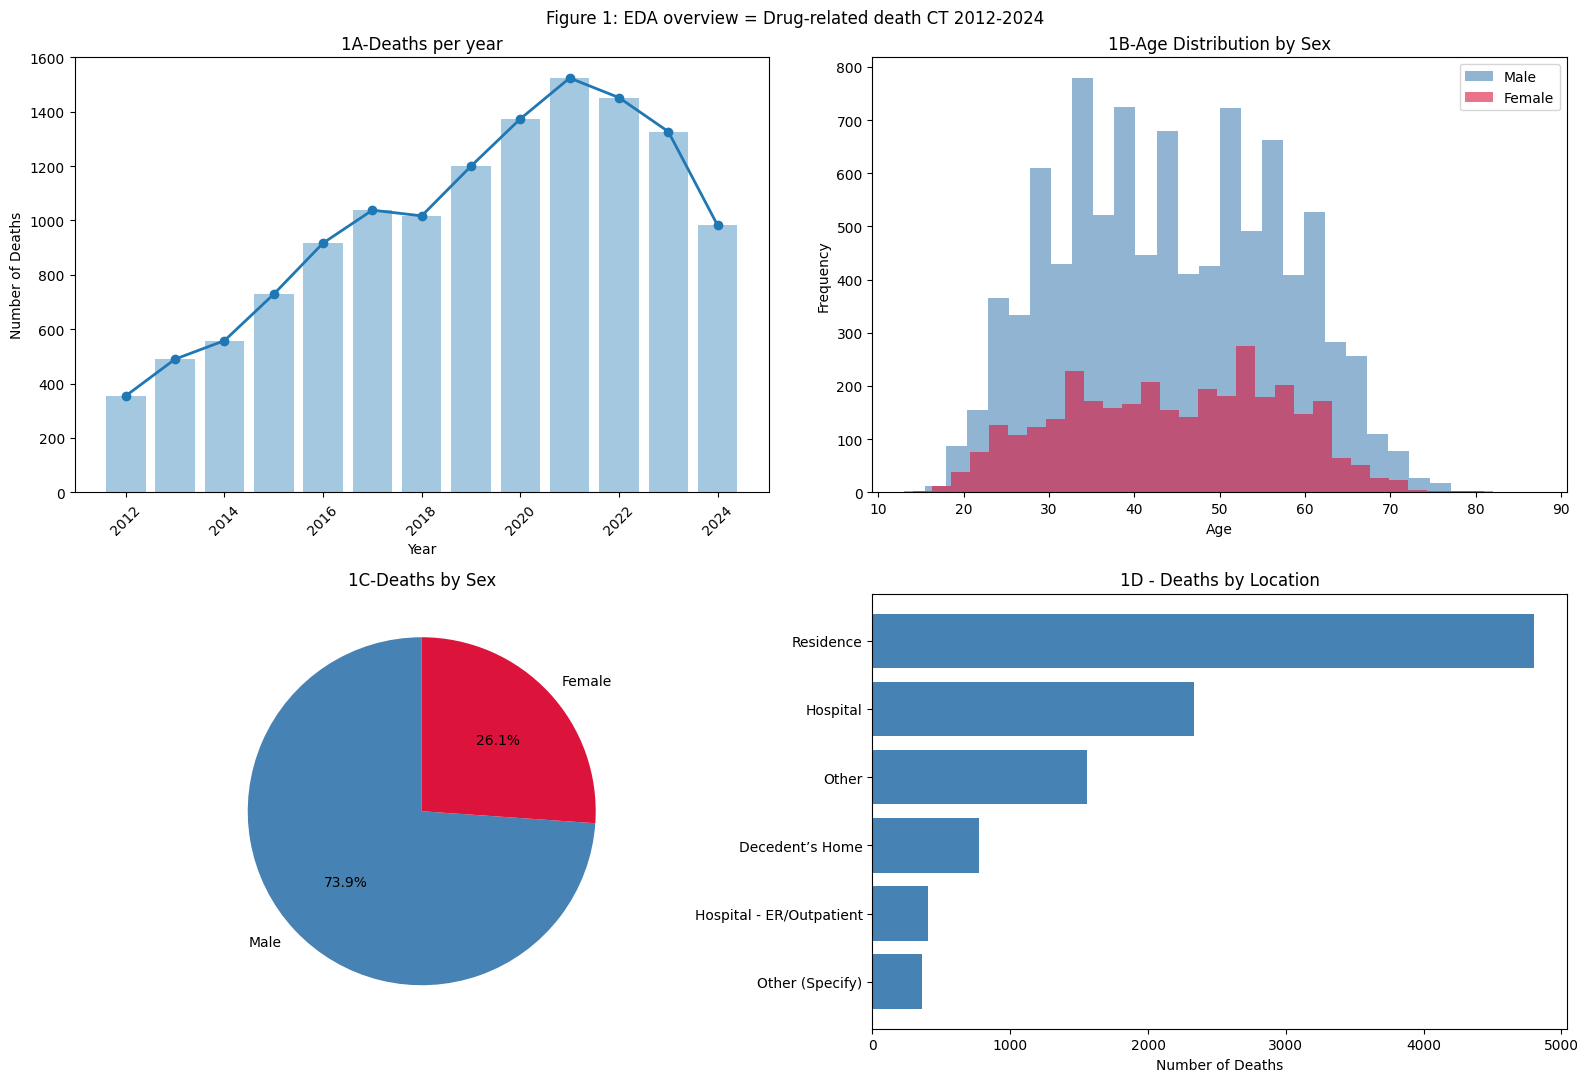

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 1: EDA overview = Drug-related death CT 2012-2024')

# 1a Death per year
ax = axes[0, 0]
yearly = df.groupby('Year').size().reset_index(name='Deaths')
ax.bar(yearly['Year'], yearly['Deaths'], alpha=0.4)
ax.plot(yearly['Year'], yearly['Deaths'], 'o-', linewidth=2)

ax.set_title('1A-Deaths per year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Deaths')
ax.tick_params(axis='x', rotation=45)

# 1b Age histogram by sex
ax = axes[0, 1]
ax.hist(df[df['Sex']=='Male']['Age'].dropna(), bins=30,
        alpha=0.6, color='steelblue', label='Male')
ax.hist(df[df['Sex']=='Female']['Age'].dropna(),bins=30,
        alpha=0.6, color='crimson', label='Female')
ax.set_title('1B-Age Distribution by Sex')
ax.set_xlabel('Age');
ax.set_ylabel('Frequency')
ax.legend()

#1C sex pie chart
ax = axes[1, 0]
sex_counts = df['Sex'].value_counts()
sex_counts = sex_counts[sex_counts.index.isin(['Male', 'Female'])]
ax.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%',
       colors=['steelblue', 'crimson'], startangle=90)
ax.set_title('1C-Deaths by Sex')

#1D Top locations
ax = axes[1, 1]
loc_counts = df['Location'].value_counts().head(6)
ax.barh(loc_counts.index[::-1], loc_counts.values[::-1], color='steelblue')
ax.set_title('1D - Deaths by Location')
ax.set_xlabel('Number of Deaths')

plt.tight_layout()
plt.savefig('fig1_eda_overview.png', dpi=150)
plt.show()

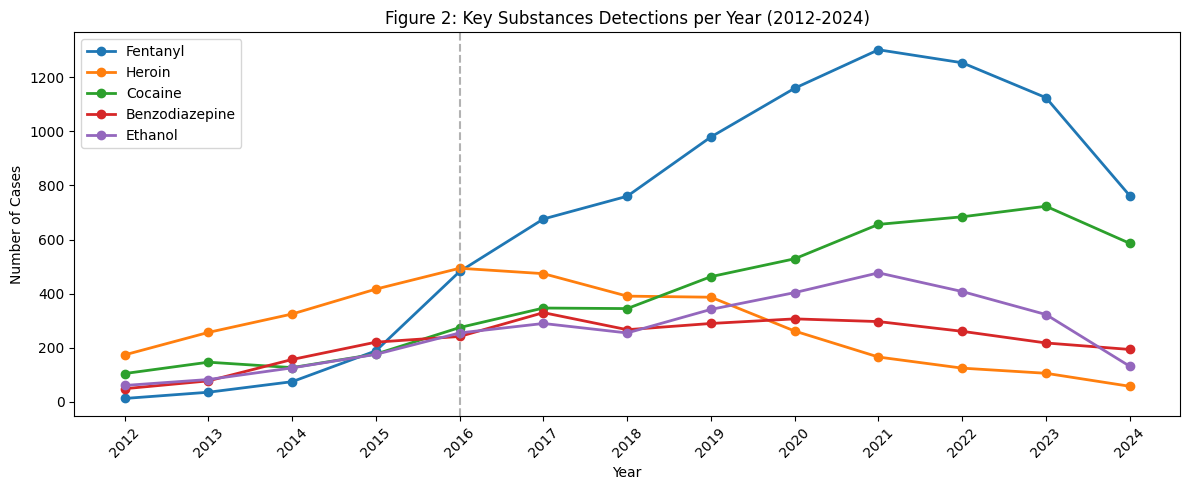

In [13]:
key_substances = ['Fentanyl', 'Heroin', 'Cocaine', 'Benzodiazepine', 'Ethanol']
colors = ['crimson', 'orange', 'steelblue', 'purple', 'green']

plt.figure(figsize=(12, 5))
for sub, col in zip(key_substances, colors):
    yearly_sub = df[df[sub] == 'Y'].groupby('Year').size()
    plt.plot(yearly_sub.index, yearly_sub.values, marker='o',
                linewidth=2, label=sub)
plt.axvline(2016, color='grey', linestyle='--', alpha=0.6)
plt.title('Figure 2: Key Substances Detections per Year (2012-2024)')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.xticks(range(2012, 2025), rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('fig2a_subtance_trends.png', dpi=150)
plt.show()

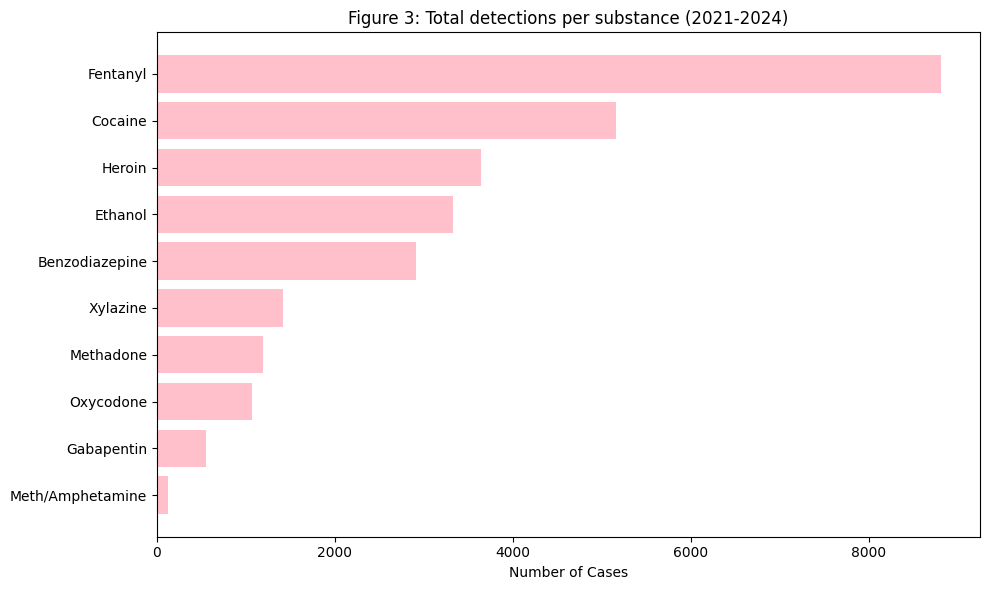

In [16]:
substance_all = ['Heroin', 'Cocaine', 'Fentanyl', 'Ethanol', 
                 'Benzodiazepine', 'Methadone','Xylazine', 
                 'Oxycodone', 'Meth/Amphetamine', 'Gabapentin']

totals = {col: (df[col] == 'Y').sum() for col in substance_all}
totals_series = pd.Series(totals).sort_values()

plt.figure(figsize=(10,6))
plt.barh(totals_series.index, totals_series.values, color='pink')
plt.title('Figure 3: Total detections per substance (2021-2024)')
plt.xlabel('Number of Cases')
plt.tight_layout()
plt.savefig('fig3_substance_totals.png', dpi=150)
plt.show()

/tmp/ipykernel_9841/2532863051.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([male_age, female_age], labels=['Male', 'Female'],


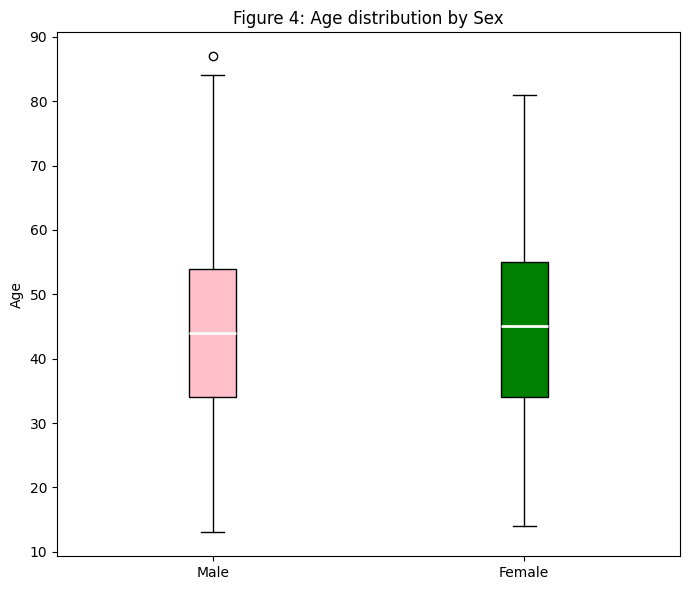

In [15]:
male_age = df[df['Sex'] == 'Male']['Age'].dropna()
female_age = df[df['Sex'] == 'Female']['Age'].dropna()

plt.figure(figsize=(7, 6))
bp = plt.boxplot([male_age, female_age], labels=['Male', 'Female'],
                 patch_artist=True,
                 medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor('pink')
bp['boxes'][1].set_facecolor('green')
plt.title('Figure 4: Age distribution by Sex')
plt.ylabel('Age')
plt.tight_layout()
plt.savefig('fig4_age_boxplot.png', dpi=150)
plt.show()

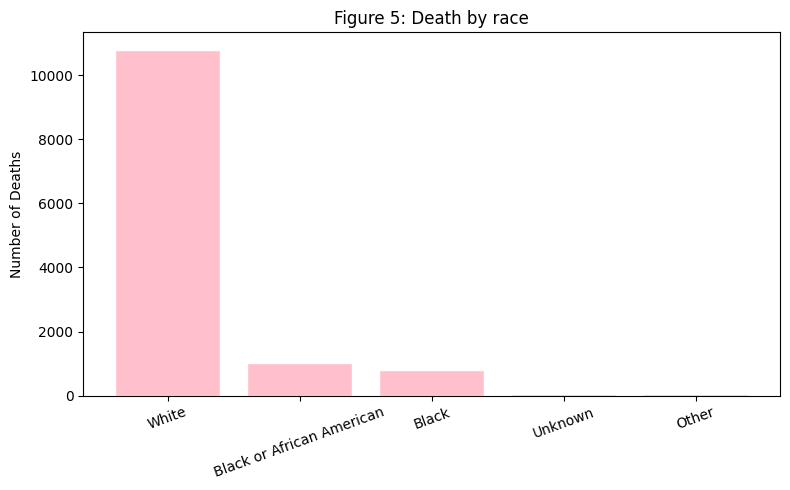

In [17]:
race_counts = df['Race'].value_counts().head(5)

plt.figure(figsize=(8, 5))
plt.bar(race_counts.index, race_counts.values, 
        color='pink', edgecolor='white')
plt.title('Figure 5: Death by race')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('fig5_race.png', dpi=150)
plt.show()

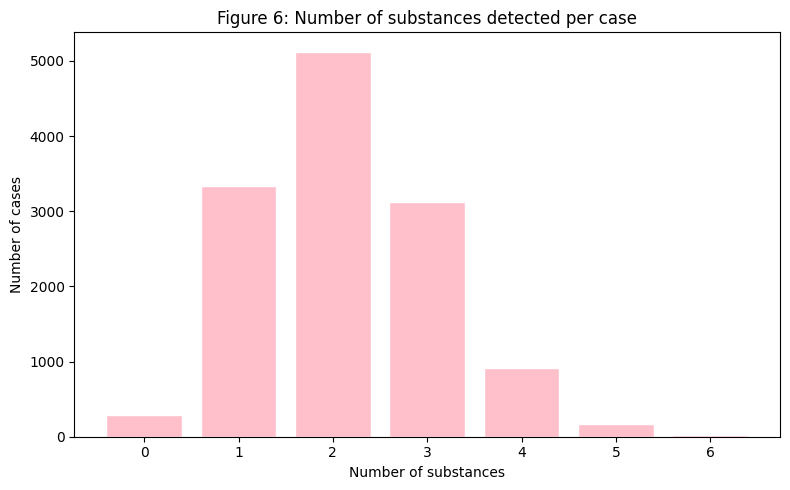

In [18]:
key_subs = ['Heroin', 'Cocaine', 'Fentanyl', 'Ethanol',
           'Benzodiazepine', 'Methadone', 'Oxycodone', 'Xylazine']
df['drug_count'] = sum((df[s] == 'Y').astype(int) for s in key_subs)
polydrug = df['drug_count'].value_counts().sort_index()
polydrug = polydrug[polydrug.index <=6]

plt.figure(figsize=(8, 5))
plt.bar(polydrug.index, polydrug.values, color='pink', edgecolor='white')
plt.title('Figure 6: Number of substances detected per case')
plt.xlabel('Number of substances')
plt.ylabel('Number of cases')
plt.xticks(polydrug.index)
plt.tight_layout()
plt.savefig('fig6_polydrug.png', dpi=150)
plt.show()

In [19]:
male_age = df[df['Sex'] == 'Male']['Age'].dropna()
female_age = df[df['Sex'] == 'Female']['Age'].dropna()

t_stat, p_value = stats.ttest_ind(male_age, female_age)
print("Independent sample t-test")
print("H0: No difference in mean age between male and female")
print("H1: Significant difference in mean age between groups")
print(f"\nMale n={len(male_age)}, mean_age = {male_age.mean():.2f}")
print(f"Female n={len(female_age)}, mean_age = {female_age.mean():.2f}")
print(f"\nt-statistics : {t_stat:.4f}")
print(f"p_value  :{p_value:.6f}")
print(f"alpha :0.05")

if p_value < 0.05:
    print("\nDecision: REJECT H0 - significant difference found")
else:
    print("\nDecision: FAIL to REJECT H0 - no significant difference")


Independent sample t-test
H0: No difference in mean age between male and female
H1: Significant difference in mean age between groups

Male n=9570, mean_age = 44.28
Female n=3380, mean_age = 44.55

t-statistics : -1.0625
p_value  :0.288025
alpha :0.05

Decision: FAIL to REJECT H0 - no significant difference


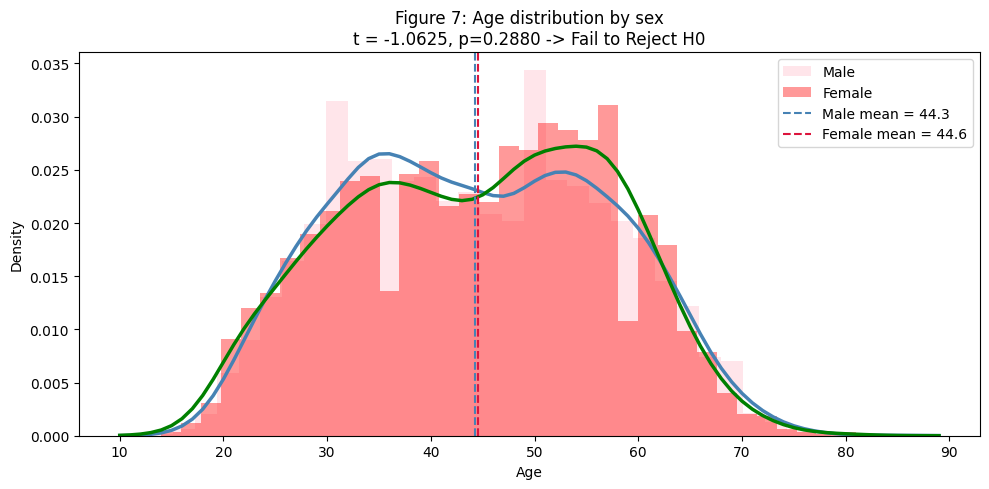

In [20]:
x = list(range(10, 90))
kde_m = gaussian_kde(male_age)
kde_f = gaussian_kde(female_age)

plt.figure(figsize=(10, 5))
plt.hist(male_age, bins=35, density=True, alpha=0.4, 
                color='pink', label='Male')
plt.hist(female_age, bins=35, density=True, alpha=0.4, 
         color='red', label='Female')
plt.plot(x, kde_m(x), color='steelblue', linewidth=2.5)
plt.plot(x, kde_f(x), color='green', linewidth=2.5)
plt.axvline(male_age.mean(), color='steelblue', linestyle='--',
            label=f'Male mean = {male_age.mean():.1f}')
plt.axvline(female_age.mean(), color='crimson', linestyle='--',
            label=f'Female mean = {female_age.mean():.1f}')
plt.title(f'Figure 7: Age distribution by sex\n'
          f't = {t_stat:.4f}, p={p_value:.4f} -> Fail to Reject H0')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('fig7_hypothesis.png', dpi=150)
plt.show()